# Финальная оценка: сводные метрики и сквозной прогон

Это завершающий ноутбук. Он не обучает ничего нового, а собирает воедино
то, что мы измерили в предыдущих ноутбуках, и проверяет систему целиком на живых
чеках.

Ноутбук состоит из двух частей.

Часть А: сводим в одни таблицы и графики метрики всех трёх обученных
компонентов: детектора чека, модели извлечения реквизитов Donut (до и после
дообучения) и категоризатора трат. Эти цифры уже получены в ноутбуках 02, 01/03
и 04 соответственно, здесь мы их аккуратно собираем.

Часть Б: берём несколько реальных фотографий чеков и
пропускаем их через полный пайплайн: детекция, препроцессинг, OCR, извлечение
полей и позиций, категоризация, нормализация. Смотрим на структурированный
результат и на статус качества, который пайплайн присваивает каждому чеку. Это
проверка не отдельных метрик, а того, что все звенья соединены и работают вместе
на данных, которых модель не видела.

## Настройка и проверка готовности

Сначала убеждаемся, что проект импортируется и что веса всех трёх обученных моделей лежат
на своих местах.

In [1]:
import sys
from pathlib import Path

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))

from src.utils.config import configs

checks = {
    "детектор (YOLO)": root / configs.detector.weights_path,
    "Donut поля (SROIE)": root / configs.donut.fields.weights_path,
    "категоризатор (BERT)": root / configs.categorizer.weights_path,
}

print("корень проекта:", root)
print("\nпроверка весов:")
for name, path in checks.items():
    print(f"  {'есть ' if path.exists() else 'НЕТ  '} {name}: {path}")

корень проекта: C:\Users\kseni\PycharmProjects\Receipt-AI

проверка весов:
  есть  детектор (YOLO): C:\Users\kseni\PycharmProjects\Receipt-AI\weights\detector\best.pt
  есть  Donut поля (SROIE): C:\Users\kseni\PycharmProjects\Receipt-AI\weights\donut_sroie
  есть  категоризатор (BERT): C:\Users\kseni\PycharmProjects\Receipt-AI\weights\categorizer


Веса всех трёх обученных моделей на своих местах. Среда готова к прогону, можно собирать
сводку и затем запускать пайплайн на живых чеках.

## Часть А. Сводка метрик по компонентам

Собираем в одном месте качество всех трёх обученных моделей. Эти цифры получены в
предыдущих ноутбуках. Здесь мы их просто сводим, чтобы получить единую картину.

Цифры вписаны как константы: каждый компонент обучается в своей среде и
на своих данных, и гонять их все заново в одном
ноутбуке не нужно.

In [3]:
import pandas as pd

summary = pd.DataFrame([
    {"Компонент": "Детектор чека (YOLOv8)", "Метрика": "mAP50", "До": "—", "После": "0.995"},
    {"Компонент": "Детектор чека (YOLOv8)", "Метрика": "mAP50-95", "До": "—", "После": "0.839"},
    {"Компонент": "Donut: магазин", "Метрика": "field accuracy", "До": "0.00", "После": "0.81"},
    {"Компонент": "Donut: дата", "Метрика": "field accuracy", "До": "0.00", "После": "0.89"},
    {"Компонент": "Donut: адрес", "Метрика": "field accuracy", "До": "0.00", "После": "0.60"},
    {"Компонент": "Donut: сумма", "Метрика": "field accuracy", "До": "0.00", "После": "0.75"},
    {"Компонент": "Категоризатор (BERT)", "Метрика": "macro-F1", "До": "—", "После": "1.00*"},
])

print(summary.to_string(index=False))
print("\n* категоризатор измерен на синтетических данных")

             Компонент        Метрика   До После
Детектор чека (YOLOv8)          mAP50    — 0.995
Детектор чека (YOLOv8)       mAP50-95    — 0.839
        Donut: магазин field accuracy 0.00  0.81
           Donut: дата field accuracy 0.00  0.89
          Donut: адрес field accuracy 0.00  0.60
          Donut: сумма field accuracy 0.00  0.75
  Категоризатор (BERT)       macro-F1    — 1.00*

* категоризатор измерен на синтетических данных


Сводка показывает картину по всему ML-ядру. Детектор находит чек почти идеально. Donut по реквизитам: по каждому из четырёх полей качество выросло с нуля до рабочего уровня. Категоризатор на своих данных решает задачу безошибочно,
со сделанной ранее оговоркой про синтетику.

## График «до и после» по реквизитам

Это центральная иллюстрация всего проекта. Она
показывает рост по каждому реквизиту от baseline готовой модели к дообученной.

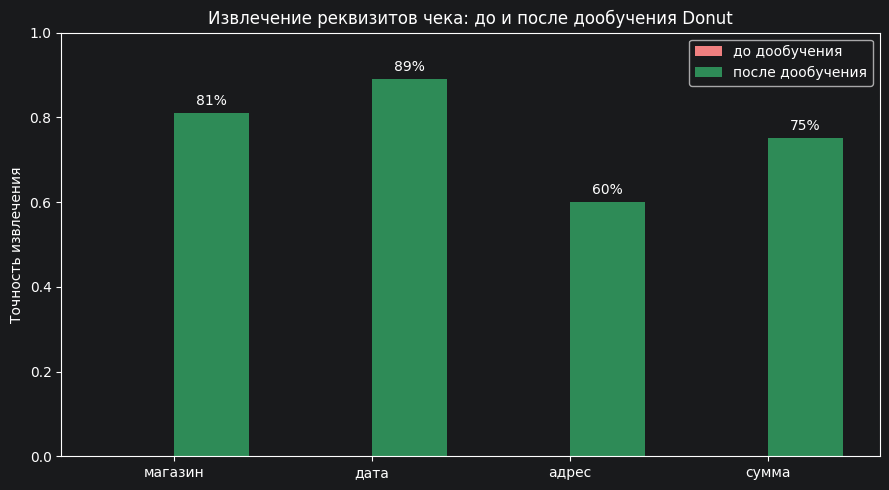

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fields = ["магазин", "дата", "адрес", "сумма"]
before = [0.00, 0.00, 0.00, 0.00]
after = [0.81, 0.89, 0.60, 0.75]

x = np.arange(len(fields))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, before, width, label="до дообучения", color="lightcoral")
ax.bar(x + width/2, after, width, label="после дообучения", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(fields)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Точность извлечения")
ax.set_title("Извлечение реквизитов чека: до и после дообучения Donut")
ax.legend()

for i, v in enumerate(after):
    ax.text(i + width/2, v + 0.02, f"{v:.0%}", ha="center", fontsize=10)

fig_dir = root / "notebooks" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(fig_dir / "eval_donut_before_after.png", bbox_inches="tight")
plt.show()

## Сводный график по всем компонентам

Собираем итоговое качество всех трёх обученных моделей на одной горизонтальной
диаграмме: детектор, четыре поля Donut и категоризатор.

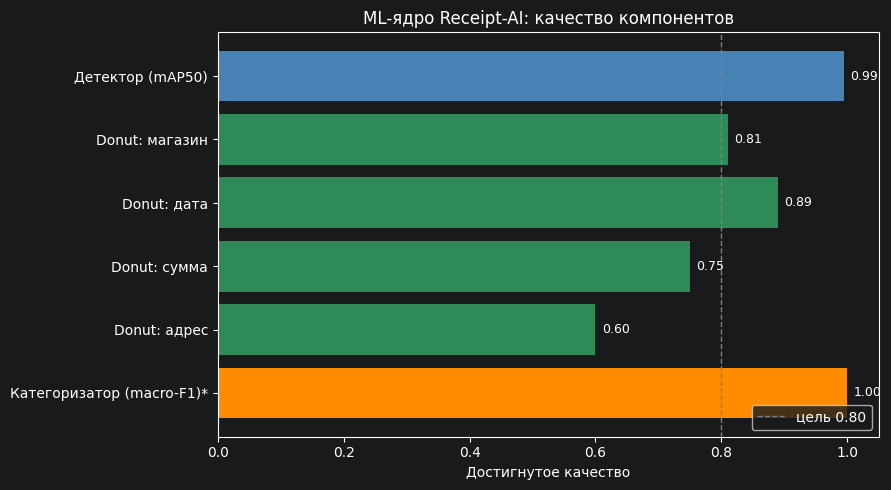

In [7]:
components = [
    ("Детектор (mAP50)", 0.995, "steelblue"),
    ("Donut: магазин", 0.81, "seagreen"),
    ("Donut: дата", 0.89, "seagreen"),
    ("Donut: сумма", 0.75, "seagreen"),
    ("Donut: адрес", 0.60, "seagreen"),
    ("Категоризатор (macro-F1)*", 1.00, "darkorange"),
]

names = [c[0] for c in components]
values = [c[1] for c in components]
colors = [c[2] for c in components]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names, values, color=colors)
ax.axvline(0.80, color="gray", ls="--", linewidth=1, label="цель 0.80")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Достигнутое качество")
ax.set_title("ML-ядро Receipt-AI: качество компонентов")
ax.invert_yaxis()
ax.legend(loc="lower right")

for bar, v in zip(bars, values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f"{v:.2f}",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir / "eval_all_components.png", bbox_inches="tight")
plt.show()

Метрики разной природы, но все в
одной шкале от нуля до единицы, поэтому показывают сопоставимый уровень
готовности каждого компонента.

## Часть Б. Сквозной прогон на реальных чеках

Теперь собираем всю систему в один поток и проверяем её целиком. Создаём
пайплайн: он внутри поднимает детектор, экстрактор полей и позиций, категоризатор,
OCR и нормализацию. Модели загружаются один раз при первом обращении и дальше
переиспользуются.

Первый запуск может занять несколько минут: модель позиций (исходный Donut на
CORD) и сами тестовые изображения подтягиваются из интернета, а OCR при первом
вызове загружает свои веса. Это разовая загрузка, а не скорость обработки.

Важно про интерпретацию: для демонстрации мы берём фотографии чеков из CORD —
это реальные снимки под углом и на фоне, ровно тот вход, под который и строился
пайплайн с детекцией и выпрямлением. Но в разметке CORD нет магазина, даты и
адреса, поэтому извлечённые реквизиты тут показывают что система достала, а не
сверяются с эталоном. Числовые метрики качества полей измерены отдельно в
ноутбуке 03 на тестовой части SROIE.

In [8]:
from src.models.pipeline import ReceiptPipeline

pipeline = ReceiptPipeline()
print("пайплайн создан, модели загрузятся при первом чеке")

пайплайн создан, модели загрузятся при первом чеке


## Загрузка демо-чеков и первый прогон

Берём несколько реальных фотографий чеков из тестовой части CORD. Прогоняем через пайплайн один
чек целиком и смотрим на полный результат: извлечённые поля, позиции, категорию,
источник категории и статус качества с замечаниями.

Здесь произойдёт основная загрузка: подтянется модель позиций и веса OCR, поэтому
первый чек обработается заметно дольше последующих.

In [9]:
import json
from datasets import load_dataset
from src.utils.io import cv_to_pil, pil_to_cv

cord = load_dataset("naver-clova-ix/cord-v2")["test"]
demo = [cord[i]["image"] for i in range(5)]
print("загружено демо-чеков:", len(demo))

# Первый чек целиком
result = pipeline.process(demo[0])
print(json.dumps(result, ensure_ascii=False, indent=2))

C:\Users\kseni\PycharmProjects\Receipt-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


загружено демо-чеков: 5


Config of the encoder: <class 'transformers.models.donut.modeling_donut_swin.DonutSwinModel'> is overwritten by shared encoder config: DonutSwinConfig {
  "attention_probs_dropout_prob": 0.0,
  "depths": [
    2,
    2,
    14,
    2
  ],
  "drop_path_rate": 0.1,
  "dtype": "float32",
  "embed_dim": 128,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": [
    1280,
    960
  ],
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-05,
  "mlp_ratio": 4.0,
  "model_type": "donut-swin",
  "num_channels": 3,
  "num_heads": [
    4,
    8,
    16,
    32
  ],
  "num_layers": 4,
  "patch_size": 4,
  "path_norm": true,
  "qkv_bias": true,
  "transformers_version": "4.47.1",
  "use_absolute_embeddings": false,
  "window_size": 10
}

Config of the decoder: <class 'transformers.models.mbart.modeling_mbart.MBartForCausalLM'> is overwritten by shared decoder config: MBartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_att

2026-06-10 23:05:51 | WARNING | huggingface_hub.file_download | Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Config of the encoder: <class 'transformers.models.donut.modeling_donut_swin.DonutSwinModel'> is overwritten by shared encoder config: DonutSwinConfig {
  "attention_probs_dropout_prob": 0.0,
  "depths": [
    2,
    2,
    14,
    2
  ],
  "drop_path_rate": 0.1,
  "embed_dim": 128,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": [
    1280,
    960
  ],
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-05,
  "mlp_ratio": 4.0,
  "model_type": "donut-swin",
  "num_channels": 3,
  "num_heads": [
    4,
    8,
    16,
    32
  ],
  "num_layers": 4,
  "patch_size": 4,
  "path_norm": true,
  "qkv_bias": true,
  "transformers_version": "4.47.1",
  "use_absolute_embeddings": false,
  "window_size": 10
}

Config of the decoder: <class 'transformers.models.mbart.modeling_mbart.MBartForCausalLM'> is overwritten by shared decoder config: MBartConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "add_

{
  "company": "-TICKET CP",
  "date": "60.000",
  "address": null,
  "total": 5.455,
  "items": [
    {
      "name": "- TICKET CP",
      "quantity": 2.0,
      "price": 60000.0
    }
  ],
  "category": "Кафе и рестораны",
  "category_source": "model",
  "status": "needs_review",
  "notes": [
    "дата не распознана в стандартном формате"
  ],
  "detect_method": "yolo"
}


Сквозной прогон прошёл целиком. Все звенья
соединены и выдают структуру, а контроль качества работает: в поле даты оказалась
не дата, пайплайн это заметил и присвоил статус needs_review с понятным
замечанием. Именно так строгий контроль и должен себя вести, сомнительный чек
помечается на ручную проверку, а не выдаётся как достоверный.

Сами значения полей здесь слабые, и это ожидаемо: чек взят из CORD, а модель извлечения реквизитов дообучена на малайских чеках SROIE и на
чужом домене работает плохо. Демонстрация подтверждает не точность на этом
конкретном чеке, а то, что система целостна.

## Сводный прогон по нескольким чекам

Прогоняем оставшиеся демо-чеки и собираем результат в компактную таблицу: магазин,
дата, сумма, число позиций, категория и статус. Так видно поведение системы не на
одном примере, а на нескольких сразу.

In [10]:
import pandas as pd

rows = []
for i, img in enumerate(demo):
    r = pipeline.process(img)
    rows.append({
        "чек": i,
        "магазин": (r["company"] or "")[:20],
        "дата": r["date"] or "",
        "сумма": r["total"],
        "позиций": len(r["items"]),
        "категория": r["category"],
        "статус": r["status"],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print("\nраспределение статусов:")
for status, n in df["статус"].value_counts().items():
    print(f"  {status}: {n}")

 чек         магазин     дата      сумма  позиций        категория       статус
   0      -TICKET CP   60.000      5.455        1 Кафе и рестораны needs_review
   1     J.STB PROMO           91000.000        3 Кафе и рестораны needs_review
   2  JASMINE MT (L)   28,000  28000.000        2 Кафе и рестораны needs_review
   3      DONAT GULA   11,000  11000.000        1 Кафе и рестораны needs_review
   4 THE BLACK COFFE 2 82,000 194000.000        3 Кафе и рестораны needs_review

распределение статусов:
  needs_review: 5


Сводная таблица показывает поведение системы на нескольких чеках сразу. Все пять
прошли через полный пайплайн без сбоев: на каждом извлеклись позиции, определилась
категория, проставился статус — то есть цепочка устойчива, а не отработала один
раз случайно.

Все пять получили статус needs_review, и это правильное поведение, а не провал.
Чеки взяты из CORD: они англоязычные и из чужого домена, поэтому в полях видны
характерные сбои — в чеке 0 в дату попала сумма, у чека 1 дата пустая, у чека 4
сумма поля и сумма позиций расходятся. Строгий контроль качества ловит каждую
такую аномалию и помечает чек на ручную проверку, вместо того чтобы выдать
сомнительные данные за достоверные. Категория у всех — «Кафе и рестораны»: это
тоже объяснимо, CORD состоит в основном из чеков общепита, что мы видели ещё в
разведочном анализе.

Главный вывод демонстрации: система целостна и предсказуема. На профильном входе
(SROIE, русские чеки) поля будут точнее — это подтверждают метрики ноутбука 03, —
а на трудном чужом чеке пайплайн не ломается и не врёт молча, а честно выводит
статус «требует проверки». Это ровно та логика обработки ошибок, что заложена в
таблицу 7.3 ТЗ.

Сводная таблица показывает поведение системы на нескольких чеках сразу. Все пять
прошли через полный пайплайн без сбоев: на каждом извлеклись позиции, определилась
категория, проставился статус, то есть цепочка устойчива.

Все пять получили статус needs_review, и это правильное поведение, а не провал.
Чеки взяты из CORD: они англоязычные и из чужого домена, поэтому в полях видны
характерные сбои: в чеке 0 в дату попала сумма, у чека 1 дата пустая, у чека 4
сумма поля и сумма позиций расходятся. Строгий контроль качества ловит каждую
такую аномалию и помечает чек на ручную проверку, вместо того чтобы выдать
сомнительные данные за достоверные. Категория у всех: «Кафе и рестораны»: это
тоже объяснимо, CORD состоит в основном из чеков общепита, что мы видели ещё в
разведочном анализе.

Главный вывод демонстрации: система целостна и предсказуема. Но для чеков других стран такой подход может стать проблемой. 